In [1]:
import pandas as pd
df = pd.read_csv('c:/data/titanic/train3.csv')
df.head()

,Survived,Pclass1,Pclass2,Pclass3,male,female,Age,SibSp,Parch,Fare
0,0,0,0,1,1,0,22.0,1,0,7.2500
1,1,1,0,0,0,1,38.0,1,0,71.2833
2,1,0,0,1,0,1,26.0,0,0,7.9250
3,1,1,0,0,0,1,35.0,1,0,53.1000
4,0,0,0,1,1,0,35.0,0,0,8.0500


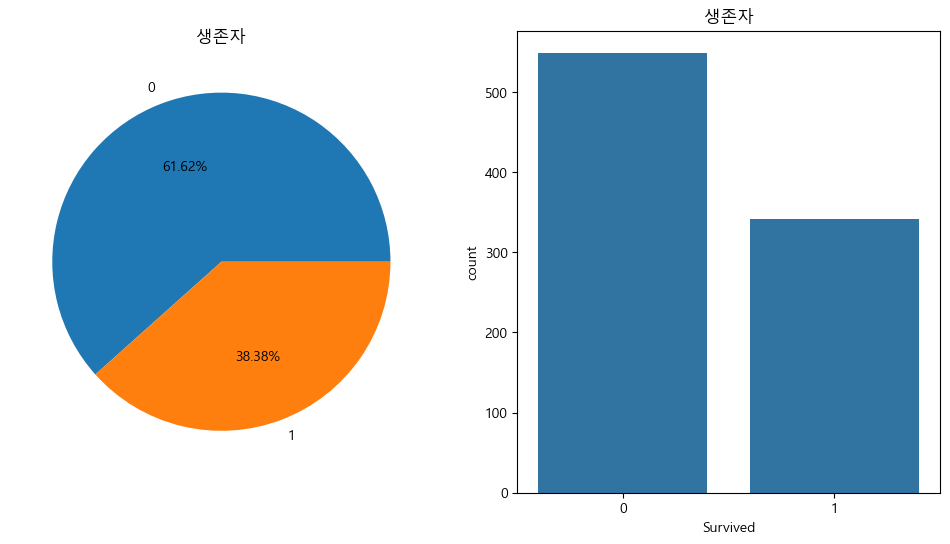

In [2]:
#생존자 비율
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager, rc
font_name = font_manager.FontProperties(fname='c:/Windows/Fonts/malgun.ttf').get_name()
rc('font', family=font_name)
f, ax = plt.subplots(1,2,figsize=(12,6))
df['Survived'].value_counts().plot.pie(autopct='%1.2f%%', ax=ax[0])
ax[0].set_title('생존자')
ax[0].set_ylabel('')
sns.countplot(x='Survived', data=df, ax=ax[1])
ax[1].set_title('생존자')
plt.show()

<Axes: >

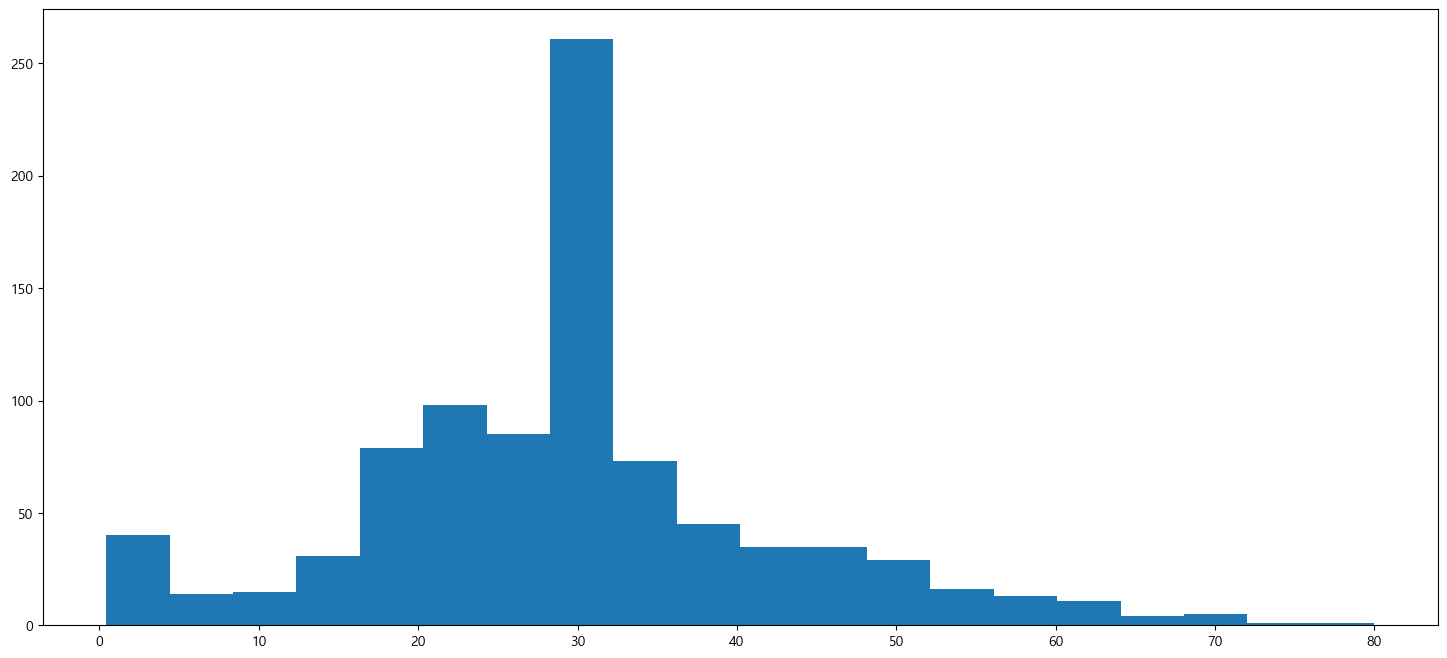

In [3]:
#승객들의 연령분포
df['Age'].hist(bins=20, figsize=(18,8), grid=False)

In [4]:
#객실등급별 통계
df.groupby('Pclass1').mean()

,Survived,Pclass2,Pclass3,male,female,Age,SibSp,Parch,Fare
Pclass1,,,,,,,,,
0,0.305185,0.272593,0.727407,0.674074,0.325926,27.412963,0.557037,0.389630,15.580055
1,0.629630,0.000000,0.000000,0.564815,0.435185,37.089907,0.416667,0.356481,84.154687


In [5]:
df.groupby('Pclass2').mean()

,Survived,Pclass1,Pclass3,male,female,Age,SibSp,Parch,Fare
Pclass2,,,,,,,,,
0,0.360679,0.305516,0.694484,0.663366,0.336634,29.726082,0.554455,0.381895,35.208073
1,0.472826,0.000000,0.000000,0.586957,0.413043,29.884946,0.402174,0.380435,20.662183


In [6]:
df.groupby('Pclass3').mean()

,Survived,Pclass1,Pclass2,male,female,Age,SibSp,Parch,Fare
Pclass3,,,,,,,,,
0,0.557500,0.54,0.46,0.575000,0.425000,33.775625,0.410000,0.367500,54.948135
1,0.242363,0.00,0.00,0.706721,0.293279,26.486599,0.615071,0.393075,13.675550


C:\python312\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.draw()
C:\python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


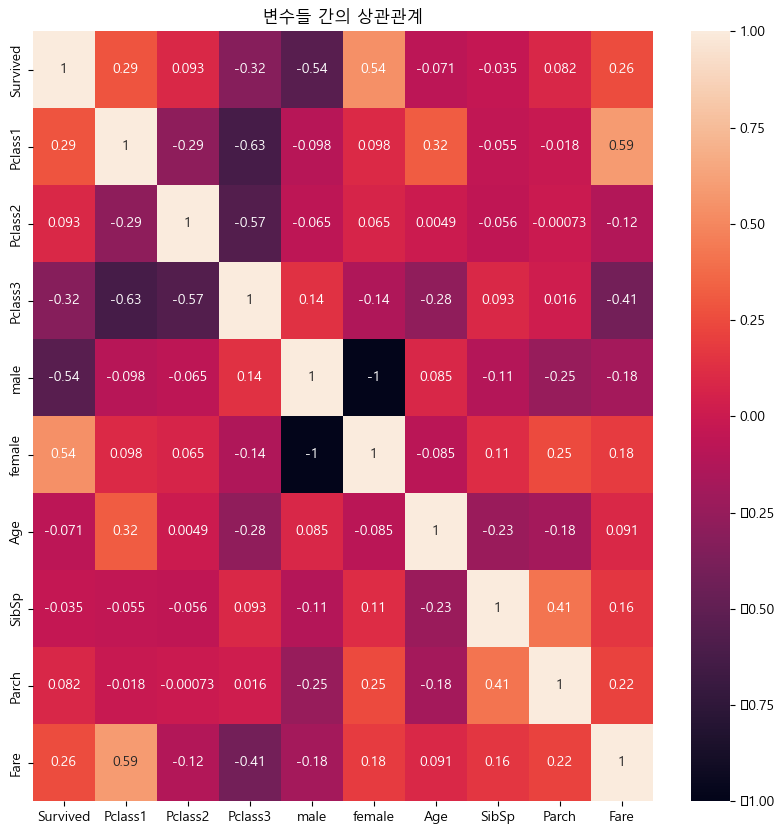

In [7]:
#상관관계 분석
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(), annot=True, linecolor='white')
plt.title('변수들 간의 상관관계')
plt.show()

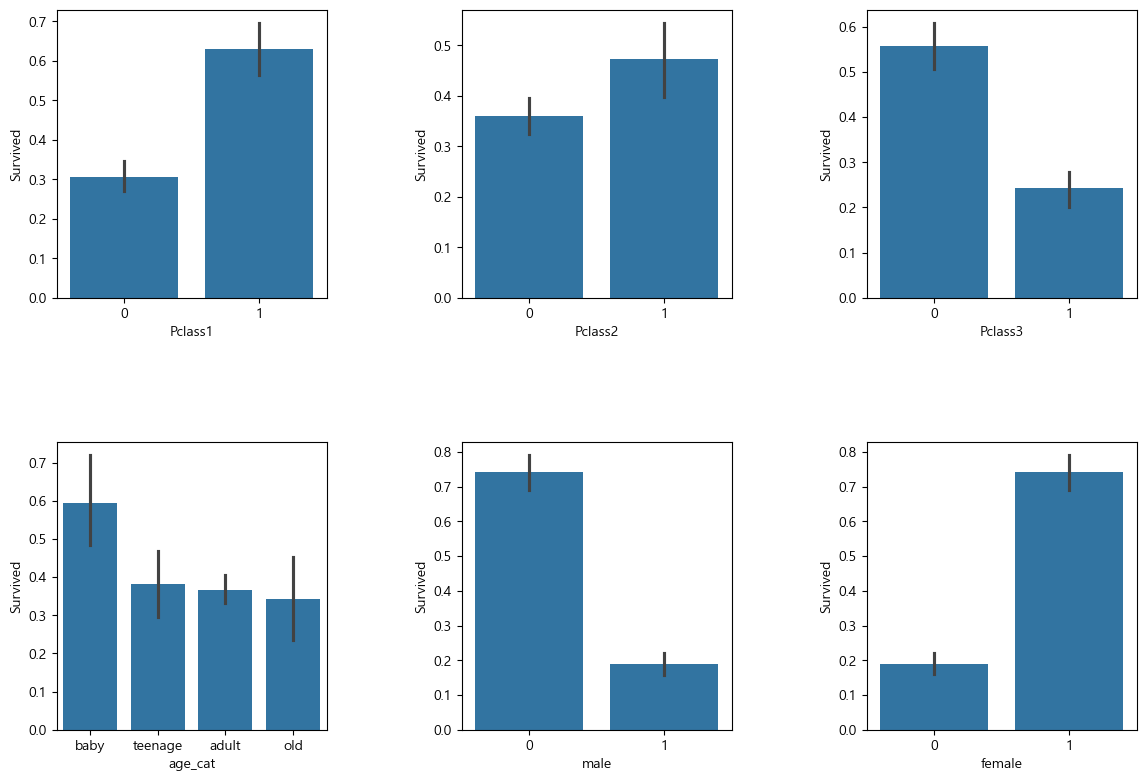

In [8]:
#연령대를 나눠서 분석
df['age_cat'] = pd.cut(df['Age'], bins=[0,10,20,50,100], include_lowest=True, labels=['baby','teenage','adult','old'])
plt.figure(figsize=(12,8))
plt.subplot(231)
sns.barplot(x='Pclass1', y='Survived', data=df)
plt.subplot(232)
sns.barplot(x='Pclass2', y='Survived', data=df)
plt.subplot(233)
sns.barplot(x='Pclass3', y='Survived', data=df)
plt.subplot(234)
sns.barplot(x='age_cat', y='Survived', data=df)
plt.subplot(235)
sns.barplot(x='male', y='Survived', data=df)
plt.subplot(236)
sns.barplot(x='female', y='Survived', data=df)
plt.subplots_adjust(top=1, bottom=0.1, left=0.1, right=1, hspace=0.5, wspace=0.5)
plt.show()

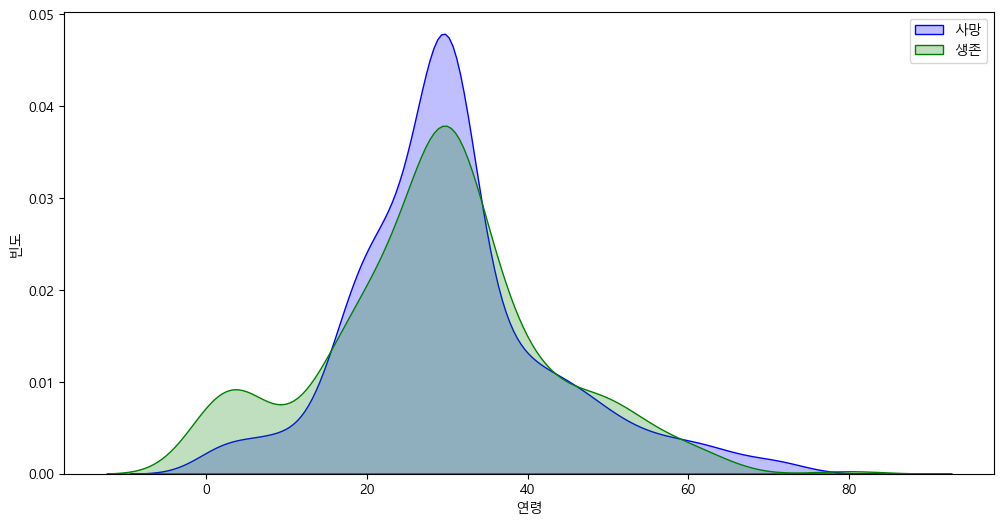

In [9]:
f, ax = plt.subplots(figsize=(12,6))
g = sns.kdeplot(df['Age'][(df['Survived'] == 0)], ax=ax, color='blue', fill=True)
g = sns.kdeplot(df['Age'][(df['Survived'] == 1)], ax=ax, color='green', fill=True)
g.set_xlabel('연령')
g.set_ylabel('빈도')
g.legend(['사망','생존'])

In [10]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [11]:
train_cols=df.columns[1:-1]
X=df[train_cols]
y=df['Survived']

In [12]:
#언더샘플링
from imblearn.under_sampling import RandomUnderSampler
X_sample, y_sample = RandomUnderSampler(random_state=0).fit_resample(X,y)
X_samp = pd.DataFrame(data=X_sample, columns=train_cols)
y_samp = pd.DataFrame(data=y_sample, columns=['Survived'])
df_samp = pd.concat([X_samp, y_samp], axis=1)

In [13]:
X = X_samp[train_cols]
y = y_samp['Survived']

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=7)

In [15]:
#신경망 모형 생성
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
model = Sequential()
model.add(Input(shape=(len(X_train.columns),)))
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='mse', optimizer='adam', metrics=['accuracy'])

In [16]:
print(len(X_train.columns))

9


In [17]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,761 (53.75 KB)

 Trainable params: 13,761 (53.75 KB)

 Non-trainable params: 0 (0.00 B)

<Axes: >

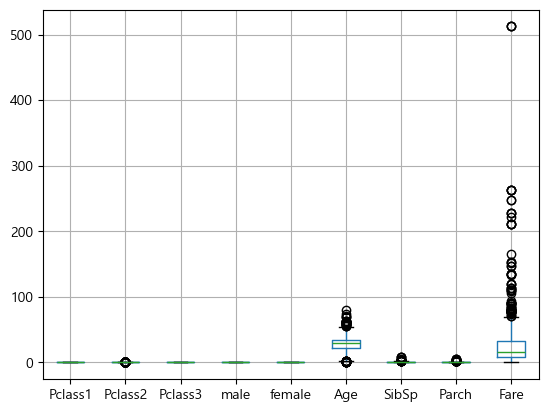

In [18]:
X_train.boxplot()

In [19]:
#스케일링
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)
#넘파이배열로 바뀜
print(X_train_scaled)

[[-0.61468183  1.94890883 -1.03535969 ... -0.49372441 -0.49451169
  -0.44320344]
 [-0.61468183 -0.51310764  0.96584791 ... -0.49372441  4.78349604
  -0.25676318]
 [ 1.62685791 -0.51310764 -1.03535969 ...  0.50652467 -0.49451169
   0.94261101]
 ...
 [ 1.62685791 -0.51310764 -1.03535969 ... -0.49372441 -0.49451169
   0.76799714]
 [-0.61468183 -0.51310764  0.96584791 ... -0.49372441 -0.49451169
  -0.50270565]
 [-0.61468183 -0.51310764  0.96584791 ... -0.49372441  2.14449217
  -0.43203818]]


In [20]:
#넘파이 배열 => 데이터프레임
X_train_scaled = pd.DataFrame(X_train_scaled)
X_test_scaled = pd.DataFrame(X_test_scaled)
print(X_train_scaled)

            0         1         2         3         4         5         6  \
0   -0.614682  1.948909 -1.035360  0.845419 -0.845419  2.474989 -0.493724   
1   -0.614682 -0.513108  0.965848 -1.182845  1.182845 -0.029869 -0.493724   
2    1.626858 -0.513108 -1.035360 -1.182845  1.182845  0.046035  0.506525   
3    1.626858 -0.513108 -1.035360  0.845419 -0.845419  1.412322  0.506525   
4    1.626858 -0.513108 -1.035360 -1.182845  1.182845  0.046035 -0.493724   
..        ...       ...       ...       ...       ...       ...       ...   
542 -0.614682 -0.513108  0.965848 -1.182845  1.182845 -2.079299  3.507272   
543  1.626858 -0.513108 -1.035360  0.845419 -0.845419  3.082227  0.506525   
544  1.626858 -0.513108 -1.035360 -1.182845  1.182845  0.046035 -0.493724   
545 -0.614682 -0.513108  0.965848  0.845419 -0.845419  0.425559 -0.493724   
546 -0.614682 -0.513108  0.965848 -1.182845  1.182845 -0.181679 -0.493724   

            7         8  
0   -0.494512 -0.443203  
1    4.783496 -0.256763

<Axes: >

C:\python312\Lib\site-packages\IPython\core\events.py:96: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  func(*args, **kwargs)
C:\python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


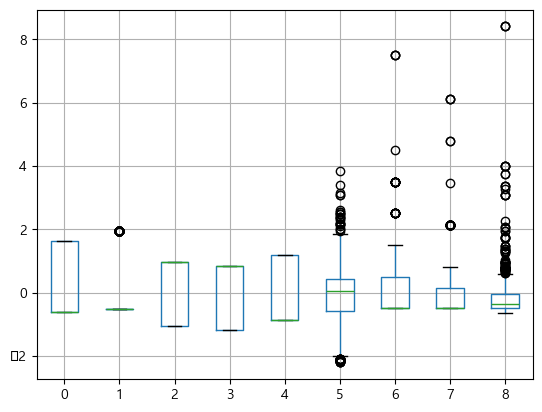

In [21]:
X_train_scaled.boxplot()

In [22]:
#스케일링 모델 저장
from joblib import dump
dump(scaler, 'c:/data/titanic/scaler.model', compress=True)

['c:/data/titanic/scaler.model']

Epoch 1/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7117 - loss: 0.2246 - val_accuracy: 0.7818 - val_loss: 0.1913
Epoch 2/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7918 - loss: 0.1674 - val_accuracy: 0.7727 - val_loss: 0.1624
Epoch 3/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7826 - loss: 0.1447 - val_accuracy: 0.7636 - val_loss: 0.1605
Epoch 4/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8009 - loss: 0.1357 - val_accuracy: 0.7818 - val_loss: 0.1595
Epoch 5/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8261 - loss: 0.1320 - val_accuracy: 0.7818 - val_loss: 0.1595
Epoch 6/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8261 - loss: 0.1278 - val_accuracy: 0.7727 - val_loss: 0.1604
Epoch 7/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8375 - loss: 0.1263 - val_accuracy: 0.7727 - val_loss: 0.1615
Epoch 8/500
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8398 - loss: 0.1234 - val_accuracy: 0.8000 - 

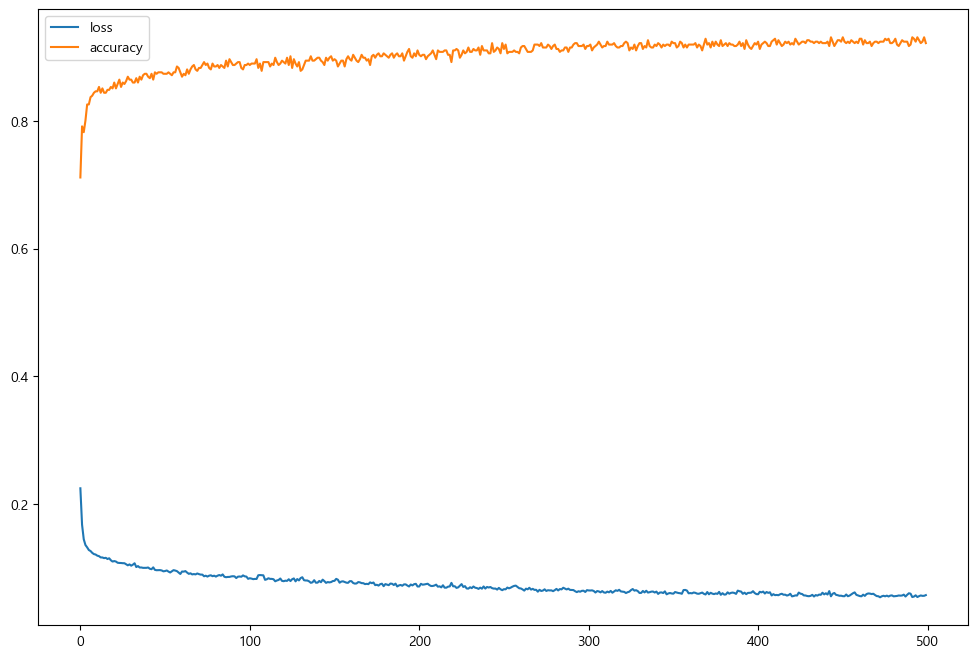

In [23]:
#모델 학습
hist = model.fit(X_train_scaled, y_train, validation_split=0.2, epochs=500)
plt.figure(figsize=(12,8))
plt.plot(hist.history['loss'])
plt.plot(hist.history['accuracy'])
plt.legend(['loss', 'accuracy'])
plt.show()

In [24]:
#모델 평가
scores = model.evaluate(X_train_scaled, y_train, verbose=1)
print(scores)
print('학습용:','%s: %.2f%%' %(model.metrics_names[1], scores[1]*100))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8848 - loss: 0.0924 
[0.0923977866768837, 0.8848263025283813]
학습용: compile_metrics: 88.48%


In [25]:
scores = model.evaluate(X_test_scaled, y_test, verbose=1)
print(scores)
print('검증용:','%s: %.2f%%' %(model.metrics_names[1], scores[1]*100))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7372 - loss: 0.2235 
[0.223530575633049, 0.7372262477874756]
검증용: compile_metrics: 73.72%


In [26]:
print(X.columns)

Index(['Pclass1', 'Pclass2', 'Pclass3', 'male', 'female', 'Age', 'SibSp',
       'Parch', 'Fare'],
      dtype='object')


In [27]:
#3등석, 남성, 19세, 형제자매2, 부모자녀0, 요금50
person1 = [[0,0,1,1,0,19,2,0,50]]
#1등석, 여성, 17세, 형제자매0, 부모자녀2, 요금30
person2 = [[1,0,0,0,1,17,0,2,30]]
#2등석, 여성, 40세, 형제자매1, 부모자녀1, 요금70
person3 = [[0,1,0,0,1,40,1,1,70]]
#스케일링을 해야 할 경우
person1=scaler.transform(person1)
person2=scaler.transform(person2)
person3=scaler.transform(person3)
print(model.predict(person1))
print(model.predict(person2))
print(model.predict(person3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
[[0.00559602]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
[[0.9999772]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


C:\python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


[[1.]]


In [28]:
model.save('c:/data/titanic/titanic.keras')